In [1]:
import os
import json
import pandas as pd
from tqdm import tqdm
from acrcloud.recognizer import ACRCloudRecognizer
import spotipy
from spotipy.oauth2 import SpotifyClientCredentials

In [73]:
import os
import json
import pandas as pd
from tqdm import tqdm
from acrcloud.recognizer import ACRCloudRecognizer
import spotipy
from spotipy.oauth2 import SpotifyClientCredentials

# --------- CONFIG ---------

# ACRCloud credentials
acr_config = {
    'host': 'identify-eu-west-1.acrcloud.com',
    'access_key': 'b5d808d71823650744d1b6dad1e5f834',
    'access_secret': 'A4mvB2XoxKinmDAesHIOHqQSUksm1IQAERYXcZAN',
    'timeout': 60  # seconds
}

# Spotify credentials
spotify_client_id = 'b87a70e388064094ad7e03dcdb757ca6'
spotify_client_secret = '802cf7fa19134a8dac89cddcfe56a48e'

# Folder with your 100 songs (WAV/MP3/FLAC, etc.)
AUDIO_FOLDER = r"C:\Polina\master\thesis\beat_this\data\SMC_MIREX\SMC_MIREX\SMC_MIREX_Audio"

# --------- INIT SERVICES ---------

acr_recognizer = ACRCloudRecognizer(acr_config)

sp = spotipy.Spotify(auth_manager=SpotifyClientCredentials(
    client_id=spotify_client_id,
    client_secret=spotify_client_secret
))

# --------- HELPERS ---------

def identify_song(file_path):
    try:
        result = acr_recognizer.recognize_by_file(file_path, 0)
        metadata = json.loads(result).get('metadata', {})
        music_info = metadata.get('music', [{}])[0]
        title = music_info.get('title')
        artist = music_info.get('artists', [{}])[0].get('name')
        return title, artist
    except Exception as e:
        print(f"Error identifying {file_path}: {e}")
        return None, None

def get_artist_genre(artist_name):
    try:
        results = sp.search(q=f'artist:{artist_name}', type='artist', limit=1)
        items = results.get('artists', {}).get('items', [])
        if items:
            return items[0].get('genres', [])
    except Exception as e:
        print(f"Error fetching genre for {artist_name}: {e}")
    return []

# --------- MAIN LOOP ---------

data = []
i = 0
for filename in tqdm(os.listdir(AUDIO_FOLDER)):
    # i += 1
    # if i > 6:
    #     break
    # else:
 
        file_path = os.path.join(AUDIO_FOLDER, filename)
        if not filename.lower().endswith(('.mp3', '.wav', '.m4a', '.flac')):
            continue

        title, artist = identify_song(file_path)
        if title and artist:
            
            genres = get_artist_genre(artist)
            
            data.append({
                'filename': filename,
                'title': title,
                'artist': artist,
                'genre': genres,
            })
        else:
            data.append({
                'filename': filename,
                'title': None,
                'artist': None,
                'genres': []
            })

df = pd.DataFrame(data)
df.to_csv('recognized_songs_with_genres.csv', index=False)
print("✅ Done! Results saved to 'recognized_songs_with_genres.csv'")

  0%|          | 0/217 [00:00<?, ?it/s]

  0%|          | 1/217 [00:00<03:15,  1.10it/s]


KeyboardInterrupt: 

In [ ]:
df = pd.read_csv("smc/gtzan_recognized_songs_with_genres.csv")

In [ ]:
empty_count = df['genre'].apply(lambda x: isinstance (x, list) and len(x)== 0).sum()  # checking nan or empty values for genres 
na = df['genre'].isna().sum()
na

np.int64(59)

In [7]:
import ast
import pandas as pd

def safe_parse_genres(x):
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except:
            return []
    return []
#df['genres_clean'] = df['genre'].apply(safe_parse_genres)

In [143]:

# Apply safely to entire column (no dropna, just handle all cases)


# Flatten the list
flattened = [genre for sublist in df_small['genres'] if isinstance(sublist, list) for genre in sublist]

# Get unique values
unique_genres = pd.Series(flattened).unique().tolist()

print(len(unique_genres))   # so far it contains 47 genres


75


In [ ]:
genre_map = {
    # Classical
    'opera': 'classical',
    'classical': 'classical',
    'chamber music': 'classical',
    'classical piano': 'classical',
    'minimalism': 'classical',
    'neoclassical': 'classical',
    'choral': 'classical',
    'requiem': 'classical',
    'orchestra': 'classical',

    # Jazz
    'jazz': 'jazz',
    'jazz fusion': 'jazz',
    'jazz funk': 'jazz',
    'smooth jazz': 'jazz',
    'french jazz': 'jazz',
    'vocal jazz': 'jazz',
    'latin jazz': 'jazz',
    'brazilian jazz': 'jazz',
    'jazz blues': 'jazz',

    # Blues
    'blues': 'blues',
    'soul jazz': 'blues',

    # HipHop
    'east coast hip hop': 'hiphop',
    'rap': 'hiphop',

    # Pop
    'neo soul': 'pop',
    'french pop': 'pop',
    'motown': 'pop',

    # Rock (stretch for things with similar attitude/feel)
    'dark cabaret': 'rock',
    'singer-songwriter': 'rock',
    'spoken word': 'rock',

    # Reggae (stretch for gospel/african gospel vibes)
    'gospel': 'reggae',
    'african gospel': 'reggae',

    # Country
    'canzone napoletana': 'country',

    # Disco
    'french house': 'disco',

    # Experimental (fallback to pop or electronic)
    'idm': 'pop',
    'glitch': 'pop',
    'electronic': 'pop',
    'experimental': 'pop',
    'ambient': 'pop',

    # Latin genres
    'flamenco': 'pop',
    'bossa nova': 'pop',
    'samba': 'pop',
    'mpb': 'pop',
    'axé': 'pop',

    # Others
    'soul': 'pop',
    'chanson': 'pop',
    'variété française': 'pop',
    'polka': 'country',
    'soundtrack': 'pop',
}

In [ ]:
def map_to_gtzan(genres):
    mapped = set()
    for g in genres:
        if g in genre_map:
            mapped.add(genre_map[g])
    return list(mapped) if mapped else ['unknown']

df['gtzan_genreS'] = df['genres_clean'].apply(map_to_gtzan)

In [ ]:
def map_to_gtzan(genres):
    mapped = set()  # use a set to avoid duplicates
    for g in genres:
       
        if g in genre_map:
            mapped.add(genre_map[g])
           
    return list(mapped) if mapped else ['unknown']
df['gtzan_genreS'] = df['genres_clean'].apply(map_to_gtzan)

In [ ]:
flattened = [genre for sublist in df['gtzan_genreS'] if isinstance(sublist, list) for genre in sublist]

# Get unique values
unique_genres = pd.Series(flattened).unique().tolist()

print(unique_genres)   # so far it contains 47 genres

['classical', 'unknown', 'pop', 'rock', 'jazz', 'blues', 'country', 'disco', 'hiphop', 'reggae']


In [ ]:
for i in range (217):
    if (len(df.iloc[i]['gtzan_genreS']) > 2):
        print(df.iloc[i]['gtzan_genreS'])

['pop', 'jazz', 'blues']


       genre  count
1    unknown     79
0  classical     56
2        pop     51
4       jazz     39
3       rock     10
8     hiphop      5
7      disco      3
6    country      3
5      blues      1
9     reggae      1


<BarContainer object of 10 artists>

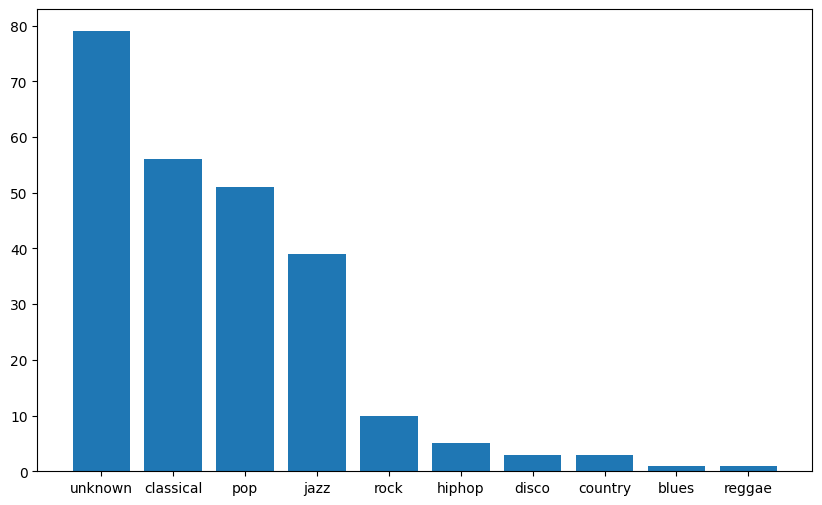

In [ ]:
from collections import Counter

# Flatten all GTZAN genre lists into one big list
all_gtzan_genres = [genre for sublist in df['gtzan_genreS'] for genre in sublist]

# Count each genre
gtzan_counts = Counter(all_gtzan_genres)

# Convert to DataFrame if you want
genre_count_df = pd.DataFrame(gtzan_counts.items(), columns=['genre', 'count']).sort_values(by='count', ascending=False)

print(genre_count_df)
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.bar(genre_count_df['genre'], genre_count_df['count'])

In [ ]:
df

,filename,title,artist,genre,genres_clean,gtzan_genre,gtzan_genreS
0,SMC_001.wav,Canon and Gigue in D Major: I. Canon,The London Symphony Orchestra,"['opera', 'classical']","[opera, classical]",classical,[classical]
1,SMC_002.wav,"""Carmen"" Fantasy, Op. 25",Budapest Strings,"['classical', 'chamber music']","[classical, chamber music]",classical,[classical]
2,SMC_003.wav,"12 Etudes: No. 4, Des accords repetes: Un peu ...",Timo Korhonen,[],[],unknown,[unknown]
3,SMC_004.wav,NaN,NaN,NaN,[],unknown,[unknown]
4,SMC_005.wav,Liebestraum No. 3,Budapest Strings,"['classical', 'chamber music']","[classical, chamber music]",classical,[classical]
...,...,...,...,...,...,...,...
212,SMC_285.wav,Montreal,Autechre,"['idm', 'glitch', 'electronic', 'experimental'...","[idm, glitch, electronic, experimental, ambient]",pop,[pop]
213,SMC_286.wav,One (feat. Erykah Badu),Busta Rhymes,['east coast hip hop'],[east coast hip hop],hiphop,[hiphop]
214,SMC_287.wav,You Had Me,Joss Stone,['neo soul'],[neo soul],pop,[pop]
215,SMC_288.wav,Party Is Goin' on over Here,Busta Rhymes,['east coast hip hop'],[east coast hip hop],hiphop,[hiphop]


In [ ]:
#df = df.drop(['genres'], axis = 1)
df.to_csv('smc/gtzan_recognized_songs_with_genreSss.csv', index=False)

In [ ]:
unknoen_count = (df['gtzan_genre'] == 'unknown').sum()
unknoen_count

np.int64(73)

In [119]:
import requests

LASTFM_API_KEY = '08f76ebf91c418b7a481e36105284eeb'

def get_track_tags(artist, title):
    try:
        url = f"http://ws.audioscrobbler.com/2.0/"
        params = {
            'method': 'track.gettoptags',
            'artist': artist,
            'track': title,
            'api_key': LASTFM_API_KEY,
            'format': 'json'
        }
        response = requests.get(url, params=params).json()
        #print(response)
        tags = response.get('toptags', {}).get('tag', [])
        return get_top_tags(tags, 2)
       # return [tag['name'].lower() for tag in tags if int(tag.get('count', 0)) > 0]
    except Exception as e:
        print(f"Error getting Last.fm tags for {title} by {artist}: {e}")
        return []
def search_track(title):
    try:
        url = "http://ws.audioscrobbler.com/2.0/"
        params = {
            "method": "track.search",
            "track": title,
            "api_key": LASTFM_API_KEY,
            "format": "json",
            "limit": 1
        }
        response = requests.get(url, params=params).json()
        trackmatches = response.get('results', {}).get('trackmatches', {}).get('track', [])
        if trackmatches:
            match = trackmatches[0]
            return match.get('artist'), match.get('name')  # return best guess
    except Exception as e:
        print(f"Track search error for '{title}': {e}")
    return None, None
def get_tags_by_title_only(title):
    artist, corrected_title = search_track(title)
    if artist and corrected_title:
        return get_track_tags(artist, corrected_title)
    return []

In [134]:
import os
import json
import pandas as pd
from tqdm import tqdm
from acrcloud.recognizer import ACRCloudRecognizer
import spotipy
from spotipy.oauth2 import SpotifyClientCredentials

# --------- CONFIG ---------

# ACRCloud credentials
acr_config = {
    'host': 'identify-eu-west-1.acrcloud.com',
    'access_key': 'b5d808d71823650744d1b6dad1e5f834',
    'access_secret': 'A4mvB2XoxKinmDAesHIOHqQSUksm1IQAERYXcZAN',
    'timeout': 60  # seconds
}

# Spotify credentials
spotify_client_id = 'b87a70e388064094ad7e03dcdb757ca6'
spotify_client_secret = '802cf7fa19134a8dac89cddcfe56a48e'

# Folder with your 100 songs (WAV/MP3/FLAC, etc.)
AUDIO_FOLDER = r"C:\Polina\master\thesis\beat_this\data\SMC_MIREX\SMC_MIREX\SMC_MIREX_Audio"

# --------- INIT SERVICES ---------

acr_recognizer = ACRCloudRecognizer(acr_config)

sp = spotipy.Spotify(auth_manager=SpotifyClientCredentials(
    client_id=spotify_client_id,
    client_secret=spotify_client_secret
))

# --------- HELPERS ---------

def identify_song(file_path):
    try:
        result = acr_recognizer.recognize_by_file(file_path, 0)
        metadata = json.loads(result).get('metadata', {})
        music_info = metadata.get('music', [{}])[0]
        title = music_info.get('title')
        artist = music_info.get('artists', [{}])[0].get('name')
        return title, artist
    except Exception as e:
        print(f"Error identifying {file_path}: {e}")
        return None, None

def get_artist_genre(artist_name):
    try:
        results = sp.search(q=f'artist:{artist_name}', type='artist', limit=1)
        items = results.get('artists', {}).get('items', [])
        if items:
            return items[0].get('genres', [])
    except Exception as e:
        print(f"Error fetching genre for {artist_name}: {e}")
    return []

# --------- MAIN LOOP ---------

data = []
i = 0
for filename in tqdm(os.listdir(AUDIO_FOLDER)):
    # i += 1
    # if i > 10:
    #     break
    # else:
 
        file_path = os.path.join(AUDIO_FOLDER, filename)
        if not filename.lower().endswith(('.mp3', '.wav', '.m4a', '.flac')):
            continue

        title, artist = identify_song(file_path)
        if title and artist:
            spotify = False
            #genres = get_track_tags(artist, title)
            genres = get_track_tags(artist, title)
            if not genres:
                genres = get_tags_by_title_only(title)  # try without artist
            if not genres:
                try:
                    genres = get_genre_lastfm(title, artist)
                except Exception as e:
                    print(e)
            if not genres:
                #print('using spotify for ' + title)
                genres = get_artist_genre(artist)   
                spotify = True
                        
            data.append({
                'filename': filename,
                'title': title,
                'artist': artist,
                'genres': genres,
                'spotify': spotify
            })
        else:
            spotify = False
            data.append({
                'filename': filename,
                'title': None,
                'artist': None,
                'genres': [],
                'spotify': spotify
            })

df_small = pd.DataFrame(data)
df_small.to_csv('lastfm_gemini_90.csv', index=False)
print("✅ Done! Results saved to 'recognized_songs_with_genres.csv'")

 27%|██▋       | 59/217 [00:57<02:43,  1.03s/it]

Expecting value: line 1 column 1 (char 0)


 55%|█████▌    | 120/217 [02:00<02:22,  1.47s/it]

Expecting value: line 1 column 1 (char 0)


 72%|███████▏  | 157/217 [02:33<00:53,  1.12it/s]

Expecting value: line 1 column 1 (char 0)


 88%|████████▊ | 191/217 [03:06<00:27,  1.06s/it]

Expecting value: line 1 column 1 (char 0)


100%|██████████| 217/217 [03:23<00:00,  1.07it/s]

✅ Done! Results saved to 'recognized_songs_with_genres.csv'


In [130]:
tags = [
    {'name': 'jazz', 'count': 1234},
    {'name': 'fusion', 'count': 567},
    {'name': 'instrumental', 'count': 1456}
]
from collections import defaultdict
def get_top_tags(tags, n):
# Step 1: Aggregate counts per tag name
    tag_freq = defaultdict(int)
    for tag in tags:
        if tag['count'] >90:
            tag_freq[tag['name']] += tag['count']

    # Step 2: Sort by total count (descending) and take top 2
    top_tags = sorted(tag_freq.items(), key=lambda x: x[1], reverse=True)[:n]

    # Optional: just names
    top_tag_names = [name for name, count in top_tags]

    return top_tag_names


In [138]:
import requests
import json
API_KEY = LASTFM_API_KEY
def get_genre_lastfm(TRACK, ARTIST):
    
    #TRACK = "Crimin' & Dealin"
    #ARTIST = "Clint Mansell"

    # Using track.getInfo
    url = f"http://ws.audioscrobbler.com/2.0/?method=track.getInfo&api_key={API_KEY}&artist={ARTIST}&track={TRACK}&format=json"
    response = requests.get(url)
    data = json.loads(response.text)
    genres = set()
    if 'track' in data and 'tags' in data['track']:
        tags = data['track']['tags']['tag']
        # print(f"Tags for {ARTIST} - {TRACK}:")
        # print(tags)
        genres.update(get_top_tags(tags, 2))
        #genres.update(tags[:3])
        # for tag in tags[:3]:
        #     print(tag['name'])
    # else:
    #     print("Could not retrieve track information or tags.")

    # Using track.getTopTags
    url = f"http://ws.audioscrobbler.com/2.0/?method=track.getTopTags&api_key={API_KEY}&artist={ARTIST}&track={TRACK}&format=json"
    response = requests.get(url)
    data = json.loads(response.text)

    if 'toptags' in data and 'tag' in data['toptags']:
        tags = data['toptags']['tag']
        # print(f"\nTop tags for {ARTIST} - {TRACK}:")
        # print(tags)
        genres.update(get_top_tags(tags, 2))
        #genres.update(tags[:3])
        # for tag in tags[:3]:
        #     print(f"{tag['name']} ({tag['count']} listeners)")
    return genres
# else:
#     print("Could not retrieve top tags.")

In [137]:
genres = get_genre_lastfm(TRACK =  "Crouching Tiger, Hidden Dragon", ARTIST = "馬友友")
genres

quintessence classical geniuses at their creepiest (100 listeners)


{'quintessence classical geniuses at their creepiest'}

In [4]:
lastfm_df = pd.read_csv('lastfm_gemini_90.csv')

In [88]:
lastfm_df
lastfm_df['genres_clean'] =lastfm_df['genres'].apply(safe_parse_genres)

In [5]:
lastfm_df

,filename,title,artist,genres,spotify
0,SMC_001.wav,Canon and Gigue in D Major: I. Canon,The London Symphony Orchestra,['classical'],True
1,SMC_002.wav,"""Carmen"" Fantasy, Op. 25",Budapest Strings,['classical'],True
2,SMC_003.wav,"12 Etudes: No. 4, Des accords repetes: Un peu ...",Timo Korhonen,[],True
3,SMC_004.wav,NaN,NaN,[],False
4,SMC_005.wav,Liebestraum No. 3,Budapest Strings,['classical'],True
...,...,...,...,...,...
212,SMC_285.wav,Montreal,Autechre,['idm'],False
213,SMC_286.wav,One (feat. Erykah Badu),Busta Rhymes,['Hip-Hop'],False
214,SMC_287.wav,You Had Me,Joss Stone,['soul'],False
215,SMC_288.wav,Party Is Goin' on over Here,Busta Rhymes,['Hip-Hop'],False


In [90]:
lastfm_df_no_classical = lastfm_df[~lastfm_df['genres_clean'].apply(lambda genres: any('classical' in g.lower() for g in genres if isinstance(g, str)))]


In [13]:
# Apply safely to entire column (no dropna, just handle all cases)
lastfm_df['genres_clean'] = lastfm_df['genres'].apply(safe_parse_genres)

# Flatten the list
flattened = [genre for sublist in lastfm_df['genres_clean']  for genre in sublist]

# Get unique values
unique_genres = pd.Series(flattened).unique().tolist()

print(unique_genres)

['classical', 'Classical', 'baroque', 'minimalism', 'The Breath of the Universe', 'soul', 'singer-songwriter', 'jazz', 'jazz fusion', 'french', 'chanson', 'folk metal', 'edith piaf', 'blues', 'chanson francaise', 'rnb', 'john dowland', 'gaillarde', 'brasil', 'rock', 'soundtrack', 'Soundtrack', 'trap', 'motown', 'vicky cristina barcelona', 'pop', 'Flamenco', 'bossa nova', 'brazilian jazz', 'samba', 'latin jazz', 'fr', 'spoken word', 'anh khoa', 'polka', '6 of 10 stars', 'piaf', 'chamber music', 'post-minimalism', 'opera', 'female vocalists', 'romantic', 'idm', 'variété française', 'french jazz', 'Soft jazz', 'orchestra', 'oldies', 'instrumental', 'mpb', 'axé', 'chillout', 'classical piano', 'piano', 'rap', 'electro', 'Hip-Hop', 'Drum and bass', 'funky', 'OpelMelange']


In [14]:
gtzan_map = {
    # Classical
    'classical': 'classical',
    'Classical': 'classical',
    'baroque': 'classical',
    'chamber music': 'classical',
    'post-minimalism': 'classical',
    'minimalism': 'classical',
    'opera': 'classical',
    'romantic': 'classical',
    'classical piano': 'classical',
    'piano': 'classical',
    'john dowland': 'classical',
    'gaillarde': 'classical',

    # Jazz
    'jazz': 'jazz',
    'jazz fusion': 'jazz',
    'latin jazz': 'jazz',
    'french jazz': 'jazz',
    'Soft jazz': 'jazz',
    'orchestra': 'jazz',
    'brazilian jazz': 'jazz',

    # Blues
    'blues': 'blues',
    'soul': 'blues',
    'motown': 'blues',
    'rnb': 'blues',

    # Pop
    'pop': 'pop',
    'spoken word': 'pop',
    'oldies': 'pop',
    'vicky cristina barcelona': 'pop',
    'soundtrack': 'pop',
    'Soundtrack': 'pop',
    'french': 'pop',
    'chanson': 'pop',
    'chanson francaise': 'pop',
    'variété française': 'pop',
    'female vocalists': 'pop',
    'edith piaf': 'pop',
    'piaf': 'pop',
    'fr': 'pop',
    'bossa nova': 'pop',
    'flamenco': 'pop',
    'brasil': 'pop',
    'samba': 'pop',
    'mpb': 'pop',
    'axé': 'pop',
    'chillout': 'pop',
    'instrumental': 'pop',
    'The Breath of the Universe': 'pop',
    'OpelMelange': 'pop',
    '6 of 10 stars': 'pop',
    'anh khoa': 'pop',

    # Rock
    'rock': 'rock',
    'singer-songwriter': 'rock',

    # Metal
    'folk metal': 'metal',

    # HipHop
    'rap': 'hiphop',
    'Hip-Hop': 'hiphop',
    'trap': 'hiphop',

    # Electronic (approximate to pop or hiphop)
    'electro': 'hiphop',
    'idm': 'hiphop',
    'Drum and bass': 'hiphop',

    # Country
    'polka': 'country',
}


In [17]:
def map_to_gtzan(genres):
    mapped = set()
    for g in genres:
        if g in gtzan_map:
            mapped.add(gtzan_map[g])
    return list(mapped) if mapped else ['unknown']

lastfm_df['gtzan_genre'] = lastfm_df['genres_clean'].apply(map_to_gtzan)

       genre  count
0  classical     88
2        pop     51
1    unknown     32
5       jazz     24
3      blues     22
7     hiphop     10
4       rock      4
8    country      2
6      metal      1


<BarContainer object of 9 artists>

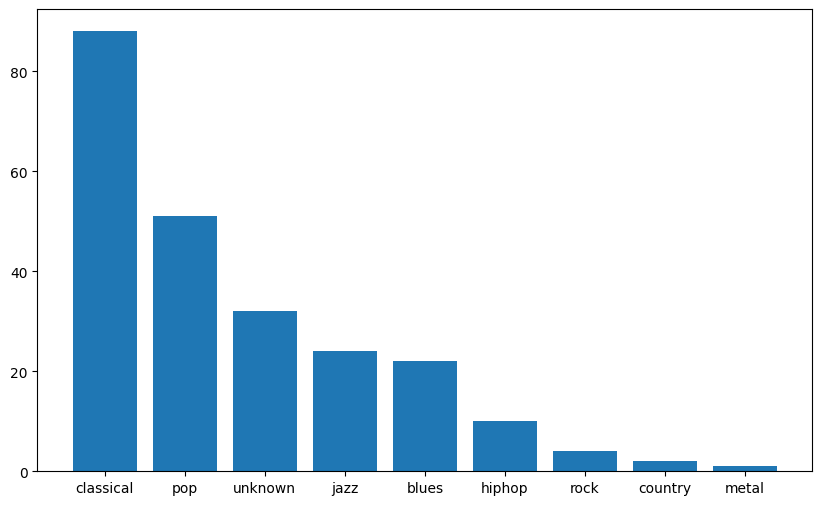

In [70]:
from collections import Counter

# Flatten all GTZAN genre lists into one big list
all_gtzan_genres = [genre for sublist in lastfm_df['gtzan_genre'] for genre in sublist]

# Count each genre
gtzan_counts = Counter(all_gtzan_genres)

# Convert to DataFrame if you want
genre_count_df = pd.DataFrame(gtzan_counts.items(), columns=['genre', 'count']).sort_values(by='count', ascending=False)

print(genre_count_df)
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.bar(genre_count_df['genre'], genre_count_df['count'])

# clustering 

In [22]:
import librosa
import numpy as np

def get_mel_spectrogram(file_path, n_mels=128, duration=30, sr=22050):
    y, _ = librosa.load(file_path, sr=sr, duration=duration)
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)
    log_mel_spec = librosa.power_to_db(mel_spec, ref=np.max)
    return log_mel_spec

In [23]:
spectrogram = get_mel_spectrogram(r"C:\Polina\master\thesis\beat_this\data\SMC_MIREX\SMC_MIREX\SMC_MIREX_Audio\SMC_001.wav")

In [25]:
spec_vector = np.mean(spectrogram, axis=1)

In [42]:
specs = []
for i in range (290):
    if i < 10:
        i = "00" + str(i)
    elif i < 100:
         i = "0" + str(i)
    file = "C:/Polina/master/thesis/beat_this/data/SMC_MIREX/SMC_MIREX/SMC_MIREX_Audio/SMC_" + str(i) + ".wav" 
    try:
        spec = get_mel_spectrogram(file)
        specs.append(np.mean(spec, axis=1))
    except Exception as e:
        print(e)  # or flatten

C:\Users\polin\AppData\Local\Temp\ipykernel_23868\3291673210.py:5: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(file_path, sr=sr, duration=duration)
c:\Polina\master\thesis\annotations\annotation\Lib\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


[Errno 2] No such file or directory: 'C:/Polina/master/thesis/beat_this/data/SMC_MIREX/SMC_MIREX/SMC_MIREX_Audio/SMC_000.wav'
[Errno 2] No such file or directory: 'C:/Polina/master/thesis/beat_this/data/SMC_MIREX/SMC_MIREX/SMC_MIREX_Audio/SMC_020.wav'
[Errno 2] No such file or directory: 'C:/Polina/master/thesis/beat_this/data/SMC_MIREX/SMC_MIREX/SMC_MIREX_Audio/SMC_025.wav'
[Errno 2] No such file or directory: 'C:/Polina/master/thesis/beat_this/data/SMC_MIREX/SMC_MIREX/SMC_MIREX_Audio/SMC_029.wav'
[Errno 2] No such file or directory: 'C:/Polina/master/thesis/beat_this/data/SMC_MIREX/SMC_MIREX/SMC_MIREX_Audio/SMC_031.wav'
[Errno 2] No such file or directory: 'C:/Polina/master/thesis/beat_this/data/SMC_MIREX/SMC_MIREX/SMC_MIREX_Audio/SMC_039.wav'
[Errno 2] No such file or directory: 'C:/Polina/master/thesis/beat_this/data/SMC_MIREX/SMC_MIREX/SMC_MIREX_Audio/SMC_040.wav'
[Errno 2] No such file or directory: 'C:/Polina/master/thesis/beat_this/data/SMC_MIREX/SMC_MIREX/SMC_MIREX_Audio/SMC_0

In [44]:
specs[0].shape

(128,)

In [45]:
from sklearn.decomposition import PCA

X = np.array(specs)
X_reduced = PCA(n_components=20).fit_transform(X)

In [46]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=10, random_state=0)
clusters = kmeans.fit_predict(X_reduced)

In [52]:
lastfm_df['clusters'] = clusters

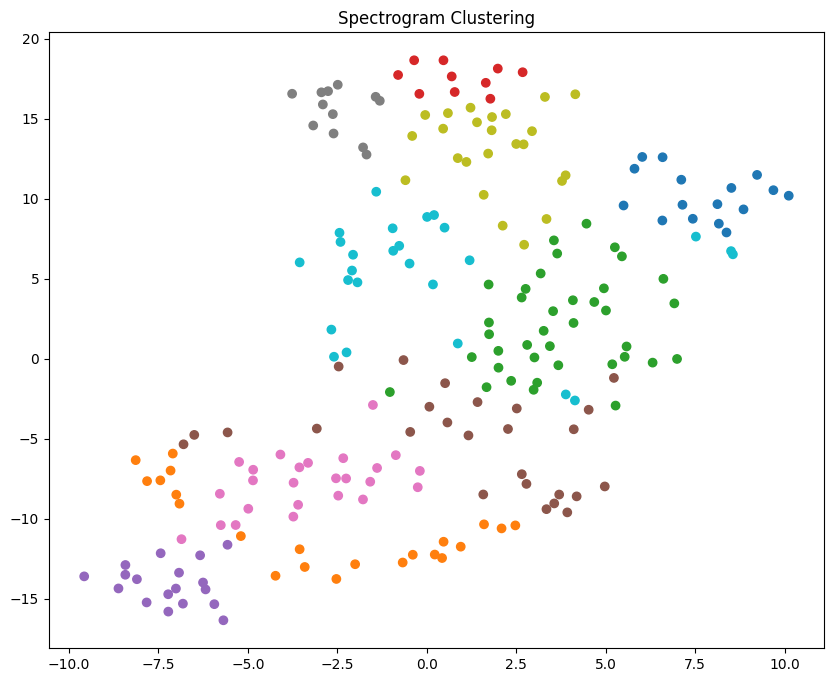

In [48]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

embedding = TSNE(n_components=2).fit_transform(X_reduced)
plt.figure(figsize=(10,8))
plt.scatter(embedding[:, 0], embedding[:, 1], c=clusters, cmap='tab10')
plt.title('Spectrogram Clustering')
plt.show()

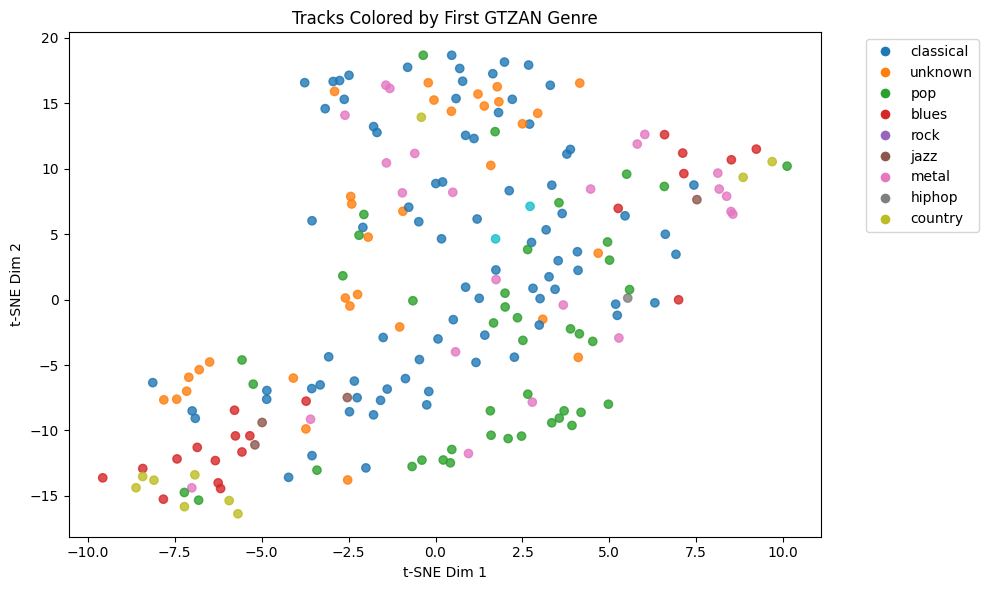

In [49]:
import matplotlib.pyplot as plt

# Step 1: Extract the first genre (as string)
lastfm_df['primary_genre'] = lastfm_df['gtzan_genre'].apply(
    lambda x: x[0] if isinstance(x, list) and len(x) > 0 else 'unknown'
)

# Step 2: Create a color palette
unique_genres = lastfm_df['primary_genre'].unique()
genre_to_color = {genre: idx for idx, genre in enumerate(unique_genres)}
colors = lastfm_df['primary_genre'].map(genre_to_color)

# Step 3: Plot
plt.figure(figsize=(10, 6))
plt.scatter(embedding[:, 0], embedding[:, 1], c=colors, cmap='tab10', alpha=0.8)
plt.title("Tracks Colored by First GTZAN Genre")
plt.xlabel("t-SNE Dim 1")
plt.ylabel("t-SNE Dim 2")

# Optional: Add legend
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w',
                          label=genre, markerfacecolor=plt.cm.tab10(i), markersize=8)
                   for genre, i in genre_to_color.items()]
plt.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [68]:
genre_to_color

{'classical': 0,
 'unknown': 1,
 'pop': 2,
 'blues': 3,
 'rock': 4,
 'jazz': 5,
 'metal': 6,
 'hiphop': 7,
 'country': 8}

In [60]:
lastfm_df.to_csv('lastfm_clusters.csv', index=False)

       genre  count
0  classical     82
2        pop     43
1    unknown     32
5       jazz     23
3      blues     20
7     hiphop     10
4       rock      4
8    country      2
6      metal      1


<BarContainer object of 9 artists>

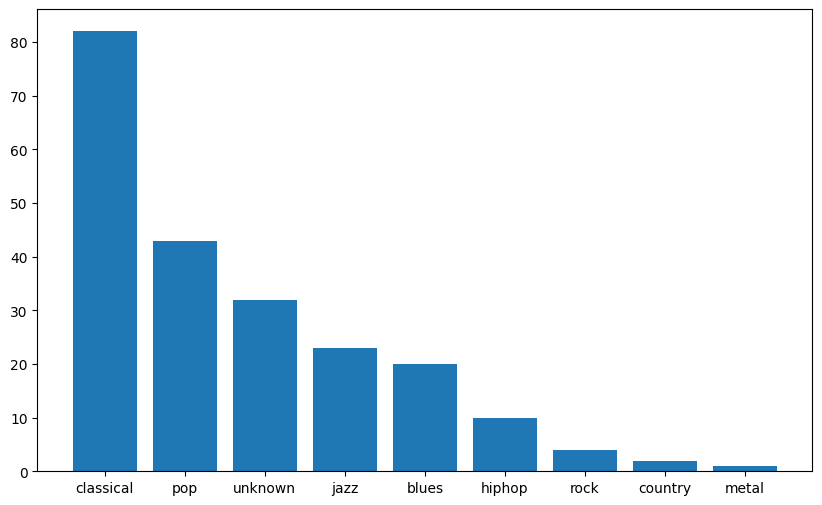

In [77]:
from collections import Counter

# Flatten all GTZAN genre lists into one big list
all_gtzan_genres = [genre for genre in lastfm_df['primary_genre'] ]

# Count each genre
gtzan_counts = Counter(all_gtzan_genres)

# Convert to DataFrame if you want
genre_count_df = pd.DataFrame(gtzan_counts.items(), columns=['genre', 'count']).sort_values(by='count', ascending=False)

print(genre_count_df)
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.bar(genre_count_df['genre'], genre_count_df['count'])

In [75]:
lastfm_df

,filename,title,artist,genres,spotify,genres_clean,gtzan_genre,primary_genre,clusters
0,SMC_001.wav,Canon and Gigue in D Major: I. Canon,The London Symphony Orchestra,['classical'],True,[classical],[classical],classical,6
1,SMC_002.wav,"""Carmen"" Fantasy, Op. 25",Budapest Strings,['classical'],True,[classical],[classical],classical,6
2,SMC_003.wav,"12 Etudes: No. 4, Des accords repetes: Un peu ...",Timo Korhonen,[],True,[],[unknown],unknown,1
3,SMC_004.wav,NaN,NaN,[],False,[],[unknown],unknown,3
4,SMC_005.wav,Liebestraum No. 3,Budapest Strings,['classical'],True,[classical],[classical],classical,6
...,...,...,...,...,...,...,...,...,...
212,SMC_285.wav,Montreal,Autechre,['idm'],False,[idm],[hiphop],hiphop,4
213,SMC_286.wav,One (feat. Erykah Badu),Busta Rhymes,['Hip-Hop'],False,[Hip-Hop],[hiphop],hiphop,0
214,SMC_287.wav,You Had Me,Joss Stone,['soul'],False,[soul],[blues],blues,4
215,SMC_288.wav,Party Is Goin' on over Here,Busta Rhymes,['Hip-Hop'],False,[Hip-Hop],[hiphop],hiphop,4
